In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

# ---- CONFIG ----
folder = Path(r"C:\Users\amitg\OneDrive\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Haiti")
glob_pattern = "Inference_results-2025-08*.csv"
selected_class_name = "1"
threshold = 0.5
num_classes = 2

fname_re = re.compile(
    r"""^Inference_results-
        (?P<inf_date>\d{4}-\d{2}-\d{2})_(?P<inf_time>\d{2}-\d{2}-\d{2})-
        .*?-
        (?P<rec_date>\d{8})_(?P<rec_time>\d{6})
        \.csv$""",
    re.VERBOSE
)

def parse_filename_times(name: str):
    m = fname_re.match(name)
    if not m:
        return None, None
    inf_date = m.group("inf_date")
    inf_time = m.group("inf_time")
    rec_date = m.group("rec_date")
    rec_time = m.group("rec_time")
    inference_dt = pd.to_datetime(f"{inf_date} {inf_time.replace('-',':')}")
    recording_dt = pd.to_datetime(f"{rec_date}_{rec_time}", format="%Y%m%d_%H%M%S")
    return inference_dt, recording_dt

def find_selected_class_column(columns, key):
    matches = [c for c in columns if key in c]
    if not matches:
        raise ValueError(f"Could not find a column containing '{key}' in {list(columns)}")
    return matches[0]

rows = []
files = sorted(folder.glob(glob_pattern))

for f in files:
    inf_dt, rec_dt = parse_filename_times(f.name)
    # use recording date for grouping
    file_date = rec_dt.date() if rec_dt is not None else None

    df = pd.read_csv(f)
    sel_col = find_selected_class_column(df.columns, selected_class_name)

    total_segments = len(df)
    positives = int((df[sel_col] > threshold).sum())
    positive_rate = positives / total_segments if total_segments else 0.0

    simple_acc = None
    if "label" in df.columns:
        prob_cols = df.columns[-int(num_classes):]
        preds = np.argmax(df[prob_cols].to_numpy(), axis=1)
        simple_acc = float((preds == df["label"].to_numpy()).mean())

    rows.append({
        "file": f.name,
        "recording_datetime": rec_dt,
        "inference_datetime": inf_dt,
        "date": file_date,  # recording date
        "total_segments": total_segments,
        "positives@thr": positives,
        "positive_rate@thr": positive_rate,
        "simple_acc_if_label": simple_acc
    })

summary = pd.DataFrame(rows)

by_date = summary.groupby("date", dropna=False).agg(
    files=("file", "count"),
    total_segments=("total_segments", "sum"),
    positives=("positives@thr", "sum")
).reset_index()
by_date["positive_rate@thr"] = by_date["positives"] / by_date["total_segments"]

summary.to_csv("haiti_file_summary.csv", index=False)
by_date.to_csv("haiti_by_date_summary.csv", index=False)

summary.head(), by_date.head()


(                                                file  recording_datetime  \
 0  Inference_results-2025-08-19_18-36-27-Manatees... 2025-05-15 14:54:51   
 1  Inference_results-2025-08-19_18-36-34-Manatees... 2025-05-15 14:55:00   
 2  Inference_results-2025-08-19_18-36-42-Manatees... 2025-05-15 14:56:00   
 3  Inference_results-2025-08-19_18-36-49-Manatees... 2025-05-15 14:57:00   
 4  Inference_results-2025-08-19_18-36-56-Manatees... 2025-05-15 14:58:00   
 
    inference_datetime        date  total_segments  positives@thr  \
 0 2025-08-19 18:36:27  2025-05-15              19              0   
 1 2025-08-19 18:36:34  2025-05-15             274              1   
 2 2025-08-19 18:36:42  2025-05-15             274              5   
 3 2025-08-19 18:36:49  2025-05-15             274             62   
 4 2025-08-19 18:36:56  2025-05-15             274             28   
 
    positive_rate@thr simple_acc_if_label  
 0           0.000000                None  
 1           0.003650           

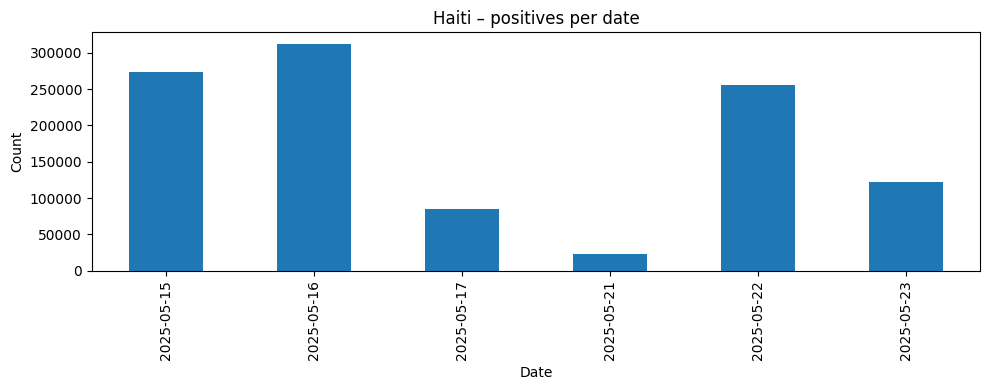

In [2]:
import matplotlib.pyplot as plt

ax = by_date.sort_values("date").plot(
    x="date", y="positives", kind="bar", figsize=(10,4), legend=False
)
ax.set_title("Haiti – positives per date")
ax.set_xlabel("Date")
ax.set_ylabel("Count")
plt.tight_layout()


C:\Users\amitg\AppData\Local\Temp\ipykernel_42264\3720625690.py:78: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minute_counts = events_series.resample("T").sum().fillna(0)
C:\Users\amitg\AppData\Local\Temp\ipykernel_42264\3720625690.py:79: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_counts = events_series.resample("H").sum().fillna(0)


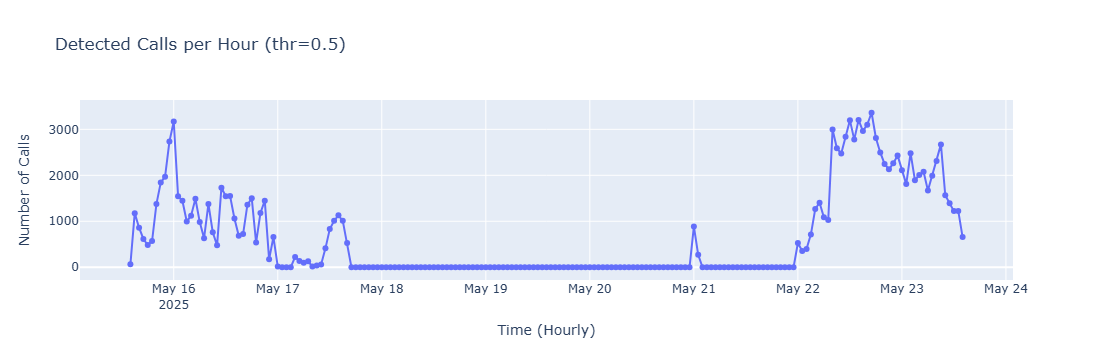

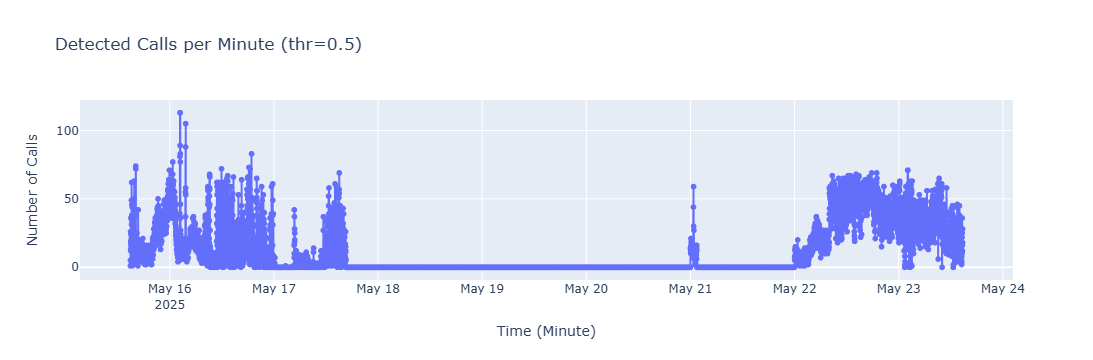

In [3]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import plotly.express as px

# -------- CONFIG --------
folder = Path(r"C:\Users\amitg\OneDrive\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Haiti")
glob_pattern = "Inference_results-2025-08*.csv"
selected_class_name = "1"
threshold = 0.5

fname_re = re.compile(
    r"""^Inference_results-
        (?P<inf_date>\d{4}-\d{2}-\d{2})_(?P<inf_time>\d{2}-\d{2}-\d{2})-
        .*?-
        (?P<rec_date>\d{8})_(?P<rec_time>\d{6})
        \.csv$""",
    re.VERBOSE
)

def parse_filename_times(name: str):
    m = fname_re.match(name)
    if not m:
        return None, None
    inf_date = m.group("inf_date")
    inf_time = m.group("inf_time")
    rec_date = m.group("rec_date")
    rec_time = m.group("rec_time")
    inference_dt = pd.to_datetime(f"{inf_date} {inf_time.replace('-',':')}")
    recording_dt = pd.to_datetime(f"{rec_date}_{rec_time}", format="%Y%m%d_%H%M%S")
    return inference_dt, recording_dt

def find_selected_class_column(columns, key):
    matches = [c for c in columns if key in c]
    if not matches:
        raise ValueError(f"Couldn't find a column containing '{key}' in {list(columns)}")
    return matches[0]

frames = []
for f in sorted(folder.glob(glob_pattern)):
    inf_dt, rec_dt = parse_filename_times(f.name)
    if rec_dt is None:
        print(f"[WARN] name doesn't match pattern, skipping: {f.name}")
        continue

    df = pd.read_csv(f)
    sel_col = find_selected_class_column(df.columns, selected_class_name)

    # Build timestamps from recording start + begin_time (or call_length fallback)
    if "begin_time" in df.columns:
        ts = rec_dt + pd.to_timedelta(df["begin_time"], unit="s")
    else:
        seq_len = df["call_length"].iloc[0] if "call_length" in df.columns else 0.2
        ts = rec_dt + pd.to_timedelta(np.arange(len(df)) * seq_len, unit="s")

    out = df.copy()
    out["timestamp"] = ts
    out["file"] = f.name
    out["_selected_prob"] = out[sel_col]
    frames.append(out)

if not frames:
    raise RuntimeError("No files matched or all skipped.")

df_all = pd.concat(frames, ignore_index=True)

# Classify predictions & detect event starts
df_all["predicted_call"] = df_all["_selected_prob"] > threshold
df_all["prev_call"] = df_all["predicted_call"].shift(fill_value=False)
df_all["call_event"] = df_all["predicted_call"] & (~df_all["prev_call"])

# Events series with DateTimeIndex
event_times = df_all.loc[df_all["call_event"], "timestamp"].sort_values()
events_series = pd.Series(1, index=pd.DatetimeIndex(event_times), dtype="int64")

# Resample
minute_counts = events_series.resample("T").sum().fillna(0)
hourly_counts = events_series.resample("H").sum().fillna(0)

minute_df = minute_counts.rename("calls").reset_index().rename(columns={"index": "timestamp"})
hourly_df = hourly_counts.rename("calls").reset_index().rename(columns={"index": "timestamp"})

# Plot
fig_h = px.line(
    hourly_df,
    x="timestamp", y="calls",
    title=f"Detected Calls per Hour (thr={threshold})",
    labels={"timestamp": "Time (Hourly)", "calls": "Number of Calls"}
)
fig_h.update_traces(mode="markers+lines", hovertemplate="Time: %{x}<br>Calls: %{y}")
fig_h.show()

fig_m = px.line(
    minute_df,
    x="timestamp", y="calls",
    title=f"Detected Calls per Minute (thr={threshold})",
    labels={"timestamp": "Time (Minute)", "calls": "Number of Calls"}
)
fig_m.update_traces(mode="markers+lines", hovertemplate="Time: %{x}<br>Calls: %{y}")
fig_m.show()
